In [1]:
import os

# Не даём transformers тянуть TensorFlow и Flax
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

import torch
from torch import nn
from transformers import AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
# ============= НАСТРОЙКА ОКРУЖЕНИЯ KAGGLE =============

import os
import sys
import numpy as np
import pandas as pd
import torch

# Kaggle paths
PROJECT_DIR = '/kaggle/working'
DATA_DIR = f'{PROJECT_DIR}/data'
MODELS_DIR = f'{PROJECT_DIR}/models'
RESULTS_DIR = f'{PROJECT_DIR}/results'

# Создать структуру директорий
os.makedirs(f'{DATA_DIR}/raw', exist_ok=True)
os.makedirs(f'{DATA_DIR}/processed', exist_ok=True)
os.makedirs(f'{MODELS_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/metrics', exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/plots', exist_ok=True)

print("="*70)
print("🚀 НАСТРОЙКА KAGGLE ОКРУЖЕНИЯ")
print("="*70)
print(f"✅ Структура директорий создана")
print(f"   PROJECT: {PROJECT_DIR}")
print(f"   DATA:    {DATA_DIR}")
print(f"   MODELS:  {MODELS_DIR}")
print(f"   RESULTS: {RESULTS_DIR}")

# Проверить GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🔧 GPU Information:")
print(f"   GPU доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   Устройство: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"   CUDA версия: {torch.version.cuda}")
else:
    print(f"   ⚠️ GPU не найден!")

# Проверить доступные датасеты
print(f"\n📂 Доступные Input датасеты:")
if os.path.exists('/kaggle/input'):
    datasets = os.listdir('/kaggle/input')
    if datasets:
        for dataset in datasets:
            print(f"   ✅ {dataset}")
    else:
        print(f"   ❌ Нет подключенных датасетов")
        print(f"   💡 Добавьте датасет: Add Data → Search 'asvspoof 2019'")
else:
    print(f"   ❌ /kaggle/input не существует")

print("="*70)


🚀 НАСТРОЙКА KAGGLE ОКРУЖЕНИЯ
✅ Структура директорий создана
   PROJECT: /kaggle/working
   DATA:    /kaggle/working/data
   MODELS:  /kaggle/working/models
   RESULTS: /kaggle/working/results

🔧 GPU Information:
   GPU доступен: True
   Устройство: Tesla T4
   VRAM: 15.8 GB
   CUDA версия: 12.4

📂 Доступные Input датасеты:
   ✅ asvpoof-2019-dataset


In [3]:
# ============= ИМПОРТЫ =============
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from transformers import AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc
)
from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_notebook
import warnings
import json
from datetime import datetime
import pickle

warnings.filterwarnings('ignore')

# Настройки для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Настройки PyTorch
torch.manual_seed(42)
np.random.seed(42)

# Определить device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✅ Все импорты успешны!")
print(f"🔧 Устройство PyTorch: {device}")


✅ Все импорты успешны!
🔧 Устройство PyTorch: cuda


In [4]:
# ============= НАСТРОЙКА ПУТЕЙ К ДАТАСЕТУ =============

# КРИТИЧНО: Определите путь к вашему датасету
# Вариант 1: Если вы подключили готовый датасет
DATASET_NAME = 'asvpoof-2019-dataset'  # Замените на имя вашего датасета
raw_dir = '/kaggle/input/asvpoof-2019-dataset'

# Вариант 2: Если датасет в другом месте
# raw_dir = '/kaggle/input/your-dataset-name'

# Проверить существование
if os.path.exists(raw_dir):
    print(f"✅ Датасет найден: {raw_dir}")
    
    # Показать структуру
    print(f"\n📂 Структура датасета:")
    for root, dirs, files in os.walk(raw_dir):
        level = root.replace(raw_dir, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < 2:  # Показать только 2 уровня
            subindent = ' ' * 2 * (level + 1)
            for file in files[:5]:  # Показать первые 5 файлов
                print(f'{subindent}{file}')
            if len(files) > 5:
                print(f'{subindent}... и ещё {len(files)-5} файлов')
        if level >= 2:
            break
else:
    print(f"❌ Датасет НЕ найден: {raw_dir}")
    print(f"\n💡 Возможные решения:")
    print(f"   1. Добавьте датасет: Add Data → Search 'asvspoof 2019'")
    print(f"   2. Загрузите свой датасет: Datasets → New Dataset")
    print(f"   3. Проверьте имя датасета в DATASET_NAME")


✅ Датасет найден: /kaggle/input/asvpoof-2019-dataset

📂 Структура датасета:
asvpoof-2019-dataset/
  asvspoof2019_Interspeech2019_submission.pdf
  LICENSE_text.txt
  README.txt
  asvspoof2019_evaluation_plan.pdf
  PA/
    PA/


In [5]:
# ============= ЯЧЕЙКА 4: ПОДГОТОВКА МЕТАДАННЫХ =============

"""
ПОДГОТОВКА МЕТАДАННЫХ ИЗ CM PROTOCOL ФАЙЛОВ
Структура датасета (как на скриншоте Kaggle):

/kaggle/input/asvpoof-2019-dataset/LA/LA/
    ASVspoof2019_LA_cm_protocols/
    ASVspoof2019_LA_train/
        flac/
    ASVspoof2019_LA_dev/
        flac/
    ASVspoof2019_LA_eval/
"""

def prepare_dataset_metadata(raw_dir: str, output_csv: str):
    """
    raw_dir: путь до /kaggle/input/asvpoof-2019-dataset/LA/LA
    """

    print(f"📂 raw_dir = {raw_dir}")

    cm_dir       = os.path.join(raw_dir, "ASVspoof2019_LA_cm_protocols")
    train_flac   = os.path.join(raw_dir, "ASVspoof2019_LA_train", "flac")
    dev_flac     = os.path.join(raw_dir, "ASVspoof2019_LA_dev", "flac")

    if not os.path.isdir(cm_dir):
        print(f"❌ Не найдена папка с CM protocol: {cm_dir}")
        return None
    if not os.path.isdir(train_flac) or not os.path.isdir(dev_flac):
        print("❌ Не найдены папки train/dev с flac-аудио")
        print("  Ожидались:")
        print(" ", train_flac)
        print(" ", dev_flac)
        return None

    print(f"✅ CM protocols: {cm_dir}")
    print(f"✅ TRAIN flac dir: {train_flac}")
    print(f"✅ DEV flac dir:   {dev_flac}")

    # ===== 1. Загрузка CM protocol-файлов =====
    protocol_files = list(Path(cm_dir).glob("*.txt"))
    print(f"✅ Найдено {len(protocol_files)} CM protocol-файлов")

    protocol_data = {}
    for protocol_file in protocol_files:
        with open(protocol_file, "r") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#"):
                    continue

                parts = line.split()
                if len(parts) < 4:
                    continue

                filename = parts[1]      # LA_T_..., LA_D_..., LA_E_...
                label_str = parts[-1]    # bonafide / spoof

                if label_str.lower() == "bonafide":
                    label = 0
                elif label_str.lower() == "spoof":
                    label = 1
                else:
                    continue

                if "_T_" in filename:
                    split = "train"
                elif "_D_" in filename:
                    split = "dev"
                elif "_E_" in filename:
                    split = "eval"
                else:
                    split = "unknown"

                protocol_data[filename] = {
                    "label": label,
                    "split": split,
                }

    print(f"✅ Загружено {len(protocol_data)} записей из CM protocol-файлов")

    # ===== 2. Сопоставление с аудиофайлами =====
    print("\n🔗 Сопоставление аудиофайлов с разметкой...")

    data_list = []

    for split_name, audio_dir in [("train", train_flac), ("dev", dev_flac)]:
        flac_files = list(Path(audio_dir).glob("*.flac"))
        print(f"   {split_name}: найдено {len(flac_files)} .flac")

        for audio_path in flac_files:
            stem = audio_path.stem  # LA_T_1234567 / LA_D_...

            if stem in protocol_data:
                meta = protocol_data[stem]
                data_list.append({
                    "filename": audio_path.name,
                    "label": meta["label"],
                    "duration": 3.0,
                    "split": split_name,
                })

    print(f"✅ Сопоставлено {len(data_list)} файлов")

    if len(data_list) == 0:
        print("❌ Не удалось сопоставить ни одного файла")
        return None

    # ===== 3. DataFrame и проверки =====
    df = pd.DataFrame(data_list)

    print("\n📊 Статистика датасета:")
    print(f"   Всего файлов: {len(df)}")

    label_counts = df["label"].value_counts()
    bonafide_count = label_counts.get(0, 0)
    spoofed_count = label_counts.get(1, 0)

    print("\n   Распределение по меткам:")
    print(f"   - Bonafide (0): {bonafide_count} ({bonafide_count/len(df)*100:.1f}%)")
    print(f"   - Spoofed (1):  {spoofed_count} ({spoofed_count/len(df)*100:.1f}%)")

    if spoofed_count == 0:
        print("\n❌ ОШИБКА: нет spoofed примеров!")
        return None

    print("\n   Распределение по split'ам:")
    for s, c in df["split"].value_counts().items():
        print(f"   - {s}: {c}")

    # ===== 4. Сохранение =====
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)
    df.to_csv(output_csv, index=False)
    print(f"\n✅ Метаданные сохранены: {output_csv}")

    return df


# ===== ВЫЗОВ ЯЧЕЙКИ =====
print("=" * 70)
print("📊 ПОДГОТОВКА МЕТАДАННЫХ ДАТАСЕТА")
print("=" * 70)

raw_dir_la = "/kaggle/input/asvpoof-2019-dataset/LA/LA"
metadata_csv = f"{DATA_DIR}/processed/asvspoof2019_metadata.csv"

df_metadata = prepare_dataset_metadata(raw_dir_la, metadata_csv)

if df_metadata is None:
    print("\n❌ КРИТИЧЕСКАЯ ОШИБКА: Не удалось создать метаданные")
else:
    print("\n✅ УСПЕШНО: Датасет подготовлен!")


📊 ПОДГОТОВКА МЕТАДАННЫХ ДАТАСЕТА
📂 raw_dir = /kaggle/input/asvpoof-2019-dataset/LA/LA
✅ CM protocols: /kaggle/input/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols
✅ TRAIN flac dir: /kaggle/input/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_train/flac
✅ DEV flac dir:   /kaggle/input/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_dev/flac
✅ Найдено 3 CM protocol-файлов
✅ Загружено 121461 записей из CM protocol-файлов

🔗 Сопоставление аудиофайлов с разметкой...
   train: найдено 25380 .flac
   dev: найдено 24986 .flac
✅ Сопоставлено 50224 файлов

📊 Статистика датасета:
   Всего файлов: 50224

   Распределение по меткам:
   - Bonafide (0): 5128 (10.2%)
   - Spoofed (1):  45096 (89.8%)

   Распределение по split'ам:
   - train: 25380
   - dev: 24844

✅ Метаданные сохранены: /kaggle/working/data/processed/asvspoof2019_metadata.csv

✅ УСПЕШНО: Датасет подготовлен!


In [6]:
# ============= ЯЧЕЙКА 5: РАЗДЕЛЕНИЕ TRAIN/VAL/TEST (С ПЕРЕМЕШИВАНИЕМ) =============

"""
РАЗДЕЛЕНИЕ ДАТАСЕТА + ПЕРЕМЕШИВАНИЕ

Критично: перемешать датасет ПЕРЕД разбиением, иначе все Spoofed в конце!
"""

# КРИТИЧНО: Перемешать датасет ПЕРЕД разбиением
df_metadata = df_metadata.sample(frac=1, random_state=42).reset_index(drop=True)
print("✅ Датасет перемешан (shuffle)")

def create_train_val_test_split(df: pd.DataFrame,
                                train_size: float = 0.7,
                                val_size: float = 0.15,
                                test_size: float = 0.15,
                                random_state: int = 42) -> tuple:
    """Разделяет датасет на train/val/test с сохранением баланса"""

    print("🔀 Разделение датасета на train/val/test...")

    total = train_size + val_size + test_size
    assert abs(total - 1.0) < 1e-6, f"Размеры должны суммироваться в 1.0, получено {total}"

    # Сначала разделить на train и (val+test)
    df_train, df_rest = train_test_split(
        df,
        test_size=(val_size + test_size),
        random_state=random_state,
        stratify=df['label']
    )

    # Потом разделить rest на val и test
    val_test_ratio = val_size / (val_size + test_size)
    df_val, df_test = train_test_split(
        df_rest,
        test_size=(1 - val_test_ratio),
        random_state=random_state,
        stratify=df_rest['label']
    )

    print(f"\n📊 Размеры наборов:")
    print(f"   Train: {len(df_train):4d} файлов ({len(df_train)/len(df)*100:5.1f}%)")
    print(f"   Val:   {len(df_val):4d} файлов ({len(df_val)/len(df)*100:5.1f}%)")
    print(f"   Test:  {len(df_test):4d} файлов ({len(df_test)/len(df)*100:5.1f}%)")

    # КРИТИЧНО: Перемешать КАЖДЫЙ набор отдельно
    df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
    df_val = df_val.sample(frac=1, random_state=42).reset_index(drop=True)
    df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"\n✅ Каждый набор перемешан")

    # Проверить баланс
    print(f"\n📊 Баланс классов:")

    def print_class_balance(name, split_df):
        bonafide = (split_df['label'] == 0).sum()
        spoofed = (split_df['label'] == 1).sum()
        total = len(split_df)
        ratio = bonafide / max(spoofed, 1)

        print(f"   {name}:")
        print(f"      Bonafide: {bonafide:5d} ({bonafide/total*100:5.1f}%)")
        print(f"      Spoofed:  {spoofed:5d} ({spoofed/total*100:5.1f}%)")
        print(f"      Ratio:    {ratio:.2f}:1")

        return bonafide, spoofed

    print_class_balance("Train", df_train)
    print_class_balance("Val", df_val)
    print_class_balance("Test", df_test)

    # Вычислить веса
    print(f"\n⚖️  ВЫЧИСЛЕНИЕ ВЕСОВ КЛАССОВ:")

    n_bonafide = (df_train['label'] == 0).sum()
    n_spoofed = (df_train['label'] == 1).sum()
    total_train = len(df_train)

    if n_spoofed > 0:
        weight_bonafide = total_train / (2 * n_bonafide)
        weight_spoofed = total_train / (2 * n_spoofed)

        print(f"   Bonafide weight: {weight_bonafide:.4f}")
        print(f"   Spoofed weight:  {weight_spoofed:.4f}")

        class_weights = {
            'bonafide': weight_bonafide,
            'spoofed': weight_spoofed
        }
        print(f"\n✅ Веса вычислены")
    else:
        print(f"   ⚠️  Нет spoofed примеров!")
        class_weights = None

    return df_train, df_val, df_test, class_weights

# Выполнить разделение
print("="*70)
print("🔀 РАЗДЕЛЕНИЕ ДАТАСЕТА")
print("="*70)

df_train, df_val, df_test, class_weights = create_train_val_test_split(df_metadata)

# Сохранить
df_train.to_csv(f'{DATA_DIR}/processed/train_split.csv', index=False)
df_val.to_csv(f'{DATA_DIR}/processed/val_split.csv', index=False)
df_test.to_csv(f'{DATA_DIR}/processed/test_split.csv', index=False)

if class_weights:
    import json
    with open(f'{DATA_DIR}/processed/class_weights.json', 'w') as f:
        json.dump(class_weights, f, indent=2)
    print(f"✅ Веса сохранены")

print(f"\n✅ Split'ы сохранены")


✅ Датасет перемешан (shuffle)
🔀 РАЗДЕЛЕНИЕ ДАТАСЕТА
🔀 Разделение датасета на train/val/test...

📊 Размеры наборов:
   Train: 35156 файлов ( 70.0%)
   Val:   7534 файлов ( 15.0%)
   Test:  7534 файлов ( 15.0%)

✅ Каждый набор перемешан

📊 Баланс классов:
   Train:
      Bonafide:  3590 ( 10.2%)
      Spoofed:  31566 ( 89.8%)
      Ratio:    0.11:1
   Val:
      Bonafide:   769 ( 10.2%)
      Spoofed:   6765 ( 89.8%)
      Ratio:    0.11:1
   Test:
      Bonafide:   769 ( 10.2%)
      Spoofed:   6765 ( 89.8%)
      Ratio:    0.11:1

⚖️  ВЫЧИСЛЕНИЕ ВЕСОВ КЛАССОВ:
   Bonafide weight: 4.8964
   Spoofed weight:  0.5569

✅ Веса вычислены
✅ Веса сохранены

✅ Split'ы сохранены


In [7]:
"""
ПРЕПРОЦЕССИНГ АУДИО

Нормализация → Фильтр высоких частот → Pad/Trim до целевой длины
"""

class AudioPreprocessor:
    """Препроцессор для аудиофайлов"""

    def __init__(self, sr: int = 16000, duration: float = 3.0):
        """
        sr: sampling rate (16 kHz - стандарт для ASVspoof)
        duration: целевая длительность в секундах
        """
        self.sr = sr
        self.duration = duration
        self.target_samples = int(sr * duration)
        print(f"✅ AudioPreprocessor инициализирован")
        print(f"   SR: {sr} Hz, Duration: {duration} sec, Samples: {self.target_samples}")

    def load_audio(self, file_path: str) -> np.ndarray:
        """Загружает аудиофайл"""
        try:
            y, sr = librosa.load(file_path, sr=self.sr, mono=True)
            return y
        except Exception as e:
            print(f"❌ Ошибка загрузки {os.path.basename(file_path)}: {e}")
            return None

    def normalize(self, audio: np.ndarray) -> np.ndarray:
        """Нормализует амплитуду аудио к [-1, 1]"""
        max_val = np.max(np.abs(audio))
        if max_val > 0:
            audio = audio / (max_val + 1e-7)
        return audio

    def high_pass_filter(self, audio: np.ndarray, cutoff_hz: float = 200) -> np.ndarray:
        """Применяет фильтр высоких частот (убирает низкочастотный шум)"""
        from scipy import signal
        sos = signal.butter(5, cutoff_hz, 'hp', fs=self.sr, output='sos')
        audio = signal.sosfilt(sos, audio)
        return audio

    def pad_or_trim(self, audio: np.ndarray) -> np.ndarray:
        """Обрезает или паддирует аудио до целевой длины"""
        if len(audio) > self.target_samples:
            # Если длиннее - обрезать с начала
            audio = audio[:self.target_samples]
        else:
            # Если короче - паддировать нулями в конце
            audio = np.pad(audio, (0, self.target_samples - len(audio)), mode='constant')
        return audio

    def preprocess(self, file_path: str) -> np.ndarray:
        """Полный препроцессинг: Load → Normalize → HPF → Pad/Trim"""

        # 1. Загрузить
        audio = self.load_audio(file_path)
        if audio is None:
            return None

        # 2. Нормализовать
        audio = self.normalize(audio)

        # 3. Фильтр высоких частот
        audio = self.high_pass_filter(audio)

        # 4. Pad/trim до целевой длины
        audio = self.pad_or_trim(audio)

        return audio

# Инициализировать препроцессор
print("="*70)
print("🔧 ИНИЦИАЛИЗАЦИЯ AUDIO PREPROCESSOR")
print("="*70)

preprocessor = AudioPreprocessor(sr=16000, duration=3.0)

# Тестировать на примере
if df_train is not None and len(df_train) > 0:
    print("\n🧪 Тестирование препроцессора на примере...")

    # Найти аудио директорию
    audio_dir = None
    if os.path.exists(f'{raw_dir}/LA/ASVspoof2019_LA_dev/flac'):
        audio_dir = f'{raw_dir}/LA/ASVspoof2019_LA_dev/flac'
    elif os.path.exists(f'{raw_dir}/ASVspoof2019_LA_dev/flac'):
        audio_dir = f'{raw_dir}/ASVspoof2019_LA_dev/flac'

    if audio_dir:
        sample_filename = df_train.iloc[0]['filename']
        sample_file = os.path.join(audio_dir, sample_filename)

        if os.path.exists(sample_file):
            audio_processed = preprocessor.preprocess(sample_file)

            if audio_processed is not None:
                print(f"✅ Препроцессинг работает!")
                print(f"   Файл: {sample_filename}")
                print(f"   Форма аудио: {audio_processed.shape}")
                print(f"   Длительность: {len(audio_processed) / 16000:.2f} сек")
                print(f"   Min/Max значения: [{audio_processed.min():.3f}, {audio_processed.max():.3f}]")

                # Визуализация
                fig, axes = plt.subplots(2, 1, figsize=(12, 6))

                # Исходное аудио
                y_raw, sr = librosa.load(sample_file, sr=16000)
                axes[0].plot(y_raw[:16000*3], linewidth=0.5, alpha=0.7)
                axes[0].set_title(f'Исходное аудио: {sample_filename}')
                axes[0].set_ylabel('Амплитуда')
                axes[0].grid(True, alpha=0.3)

                # Обработанное аудио
                axes[1].plot(audio_processed, linewidth=0.5, alpha=0.7, color='orange')
                axes[1].set_title('Обработанное аудио (Нормализовано + HPF + Pad)')
                axes[1].set_ylabel('Амплитуда')
                axes[1].set_xlabel('Сэмпл')
                axes[1].grid(True, alpha=0.3)

                plt.tight_layout()
                plt.savefig(f'{RESULTS_DIR}/plots/preprocessing_example.png', dpi=100, bbox_inches='tight')
                plt.show()

                print(f"✅ График сохранён!")


🔧 ИНИЦИАЛИЗАЦИЯ AUDIO PREPROCESSOR
✅ AudioPreprocessor инициализирован
   SR: 16000 Hz, Duration: 3.0 sec, Samples: 48000

🧪 Тестирование препроцессора на примере...


In [8]:
"""
PYTORCH DATASET
Класс для загрузки данных во время обучения с on-the-fly препроцессингом
"""

# КРИТИЧНО: Определить raw_dir перед использованием
raw_dir = '/kaggle/input/asvpoof-2019-dataset'

# Найти ВСЕ audio директории (train, dev, eval)
print("="*70)
print("🔨 СОЗДАНИЕ PYTORCH DATASET'ОВ (ИСПРАВЛЕННАЯ ВЕРСИЯ)")
print("="*70)

# Найти все возможные директории с аудио
audio_dirs = {}
possible_paths = [
    (f'{raw_dir}/LA/LA/ASVspoof2019_LA_train/flac', 'train'),
    (f'{raw_dir}/LA/LA/ASVspoof2019_LA_dev/flac', 'dev'),
    (f'{raw_dir}/LA/LA/ASVspoof2019_LA_eval/flac', 'eval'),
]

for path, split_name in possible_paths:
    if os.path.exists(path):
        audio_dirs[split_name] = path
        print(f"✅ Найдена директория {split_name}: {path}")

if not audio_dirs:
    print("❌ Ни одна audio директория не найдена!")
    print(f"   Проверяем путь: {raw_dir}")
    print(f"   Содержимое {DATA_DIR}/raw:")
    if os.path.exists(f'{DATA_DIR}/raw'):
        for item in os.listdir(f'{DATA_DIR}/raw'):
            print(f"     - {item}")
    raise FileNotFoundError("Audio directories not found")

# ... остальной код класса ASVspoofDatasetFixed ...


# ИСПРАВЛЕННЫЙ класс Dataset с автоматическим поиском файлов
class ASVspoofDatasetFixed(Dataset):
    """Dataset для ASVspoof с автоматическим поиском файлов"""
    
    def __init__(self, csv_path: str, audio_dirs: dict, preprocessor: AudioPreprocessor):
        """
        csv_path: путь к CSV с метаданными
        audio_dirs: словарь {split_name: path} с директориями аудио
        preprocessor: AudioPreprocessor для обработки аудио
        """
        # Загрузить метаданные
        self.df = pd.read_csv(csv_path)
        self.audio_dirs = audio_dirs
        self.preprocessor = preprocessor
        
        # Создать кэш путей к файлам для быстрого доступа
        self.file_cache = {}
        missing_files = []
        
        print(f"📂 Создание кэша путей к файлам...")
        for idx, row in tqdm_notebook(self.df.iterrows(), total=len(self.df), desc="Кэширование"):
            filename = row['filename']
            found = False
            
            # Попробовать найти файл во всех доступных директориях
            for split_name, audio_dir in self.audio_dirs.items():
                filepath = os.path.join(audio_dir, filename)
                if os.path.exists(filepath):
                    self.file_cache[idx] = filepath
                    found = True
                    break
            
            if not found:
                missing_files.append(filename)
        
        if missing_files:
            print(f"⚠️  Не найдено {len(missing_files)} файлов из {len(self.df)}")
            if len(missing_files) <= 10:
                print(f"   Примеры: {missing_files[:10]}")
        else:
            print(f"✅ Все {len(self.df)} файлов найдены!")
        
        print(f"📊 Dataset статистика:")
        print(f"   Всего файлов: {len(self.df)}")
        print(f"   - Bonafide: {(self.df['label'] == 0).sum()}")
        print(f"   - Spoofed: {(self.df['label'] == 1).sum()}")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        """Возвращает (аудио_тензор, метка)"""
        row = self.df.iloc[idx]
        
        # Получить путь из кэша
        if idx in self.file_cache:
            audio_path = self.file_cache[idx]
        else:
            # Если файл не в кэше, вернуть тишину
            audio = np.zeros(self.preprocessor.target_samples)
            label = int(row['label'])
            audio_tensor = torch.FloatTensor(audio)
            return audio_tensor, label
        
        # Препроцессинг
        audio = self.preprocessor.preprocess(audio_path)
        
        if audio is None:
            # Если ошибка - вернуть тишину
            audio = np.zeros(self.preprocessor.target_samples)
        
        # Метка класса
        label = int(row['label'])
        
        # Конвертировать в torch tensor
        audio_tensor = torch.FloatTensor(audio)
        
        return audio_tensor, label

# Создать Dataset'ы с исправленным классом
train_dataset = ASVspoofDatasetFixed(
    csv_path=f'{DATA_DIR}/processed/train_split.csv',
    audio_dirs=audio_dirs,
    preprocessor=preprocessor
)

val_dataset = ASVspoofDatasetFixed(
    csv_path=f'{DATA_DIR}/processed/val_split.csv',
    audio_dirs=audio_dirs,
    preprocessor=preprocessor
)

test_dataset = ASVspoofDatasetFixed(
    csv_path=f'{DATA_DIR}/processed/test_split.csv',
    audio_dirs=audio_dirs,
    preprocessor=preprocessor
)

print(f"\n✅ Dataset'ы созданы:")
print(f"   Train: {len(train_dataset)} файлов")
print(f"   Val:   {len(val_dataset)} файлов")
print(f"   Test:  {len(test_dataset)} файлов")

# Тестировать получение одного образца
print(f"\n🧪 Тестирование получения образца:")
audio_sample, label_sample = train_dataset[0]
label_name = 'Bonafide' if label_sample == 0 else 'Spoofed'
print(f"   Audio shape: {audio_sample.shape}")
print(f"   Label: {label_sample} ({label_name})")
print(f"   Audio stats: min={audio_sample.min():.3f}, max={audio_sample.max():.3f}, mean={audio_sample.mean():.3f}")

# КРИТИЧЕСКАЯ ПРОВЕРКА: убедиться что аудио НЕ нулевое
if audio_sample.abs().sum() == 0:
    print("\n❌ КРИТИЧЕСКАЯ ОШИБКА: Аудио состоит из нулей!")
    print("   Файлы не загружаются правильно")
else:
    print("\n✅ Аудио загружено корректно (не нули)")


🔨 СОЗДАНИЕ PYTORCH DATASET'ОВ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
✅ Найдена директория train: /kaggle/input/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_train/flac
✅ Найдена директория dev: /kaggle/input/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_dev/flac
✅ Найдена директория eval: /kaggle/input/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_eval/flac
📂 Создание кэша путей к файлам...


Кэширование:   0%|          | 0/35156 [00:00<?, ?it/s]

✅ Все 35156 файлов найдены!
📊 Dataset статистика:
   Всего файлов: 35156
   - Bonafide: 3590
   - Spoofed: 31566
📂 Создание кэша путей к файлам...


Кэширование:   0%|          | 0/7534 [00:00<?, ?it/s]

✅ Все 7534 файлов найдены!
📊 Dataset статистика:
   Всего файлов: 7534
   - Bonafide: 769
   - Spoofed: 6765
📂 Создание кэша путей к файлам...


Кэширование:   0%|          | 0/7534 [00:00<?, ?it/s]

✅ Все 7534 файлов найдены!
📊 Dataset статистика:
   Всего файлов: 7534
   - Bonafide: 769
   - Spoofed: 6765

✅ Dataset'ы созданы:
   Train: 35156 файлов
   Val:   7534 файлов
   Test:  7534 файлов

🧪 Тестирование получения образца:
   Audio shape: torch.Size([48000])
   Label: 1 (Spoofed)
   Audio stats: min=-0.733, max=0.721, mean=0.000

✅ Аудио загружено корректно (не нули)


In [9]:
from torch.utils.data import WeightedRandomSampler

# Параметры
batch_size = 32  # Увеличил с 16 до 32
num_workers = 2
pin_memory = True

print("="*70)
print("⚙️  СОЗДАНИЕ DATALOADERS (С БАЛАНСИРОВКОЙ)")
print("="*70)

# Создать веса для сэмплера (балансировка классов)
train_labels = train_dataset.df['label'].values
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# TRAIN LOADER с сэмплером
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,  # Используем sampler вместо shuffle
    num_workers=num_workers,
    pin_memory=pin_memory,
    drop_last=True
)

print(f"\n✅ Train loader создан")
print(f"   Батчей: {len(train_loader)}")
print(f"   Batch size: {batch_size}")

# Проверить батчи
print(f"\n✅ Проверка батчей:")
for batch_idx, (audio, labels) in enumerate(train_loader):
    if batch_idx >= 5:
        break
    bonafide = (labels == 0).sum()
    spoofed = (labels == 1).sum()
    print(f"   Батч {batch_idx}: Bonafide={bonafide}, Spoofed={spoofed}")

# VAL LOADER
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

print(f"\n✅ Val loader создан")
print(f"   Батчей: {len(val_loader)}")

print("\n" + "="*70)
print("✅ DATALOADERS ГОТОВЫ")
print("="*70)


⚙️  СОЗДАНИЕ DATALOADERS (С БАЛАНСИРОВКОЙ)

✅ Train loader создан
   Батчей: 1098
   Batch size: 32

✅ Проверка батчей:
   Батч 0: Bonafide=13, Spoofed=19
   Батч 1: Bonafide=15, Spoofed=17
   Батч 2: Bonafide=16, Spoofed=16
   Батч 3: Bonafide=14, Spoofed=18
   Батч 4: Bonafide=14, Spoofed=18

✅ Val loader создан
   Батчей: 236

✅ DATALOADERS ГОТОВЫ


In [ ]:
!pip install -q "protobuf==4.24.4" "transformers>=4.40,<5" "accelerate>=0.27,<0.33"


In [10]:
# ============= ДИАГНОСТИКА WAVLM =============

# Определить device, если ещё не определено
if 'device' not in dir():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🔧 Устройство: {device}")
    
class WavLMFeatureExtractor(nn.Module):
    """Извлекатель признаков WavLM с правильной обработкой выхода"""

    def __init__(self, model_name: str = "microsoft/wavlm-large"):
        super().__init__()

        print(f"📥 Загрузка {model_name}...")
        self.model = AutoModel.from_pretrained(model_name)

        # КРИТИЧНО: Проверить выходную размерность
        config = self.model.config
        self.hidden_dim = config.hidden_size
        print(f"✅ WavLM Hidden Dimension: {self.hidden_dim}")

        # Заморозить параметры
        for param in self.model.parameters():
            param.requires_grad = False

        self.model.eval()
        print(f"✅ WavLM загружена и заморожена!")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Входные данные: [batch_size, num_samples]
        Выходные данные: [batch_size, seq_len, hidden_dim]
        """
        with torch.no_grad():
            outputs = self.model(x, output_hidden_states=False)
            embeddings = outputs.last_hidden_state  # [B, T, hidden_dim]
        return embeddings

# Загрузить и проверить
print("="*70)
print("🔧 ДИАГНОСТИКА WAVLM")
print("="*70)

wavlm_extractor = WavLMFeatureExtractor(model_name="microsoft/wavlm-large")
wavlm_extractor = wavlm_extractor.to(device)

# ТЕСТИРОВАНИЕ - ОЧЕНЬ ВАЖНО!
print(f"\n🧪 ТЕСТИРОВАНИЕ WAVLM ВЫХОДА:")
with torch.no_grad():
    test_audio = torch.randn(2, 16000*3).to(device)  # [2, 48000]
    test_embeddings = wavlm_extractor(test_audio)

    print(f"   Input shape:  {test_audio.shape} (batch=2, samples=48000)")
    print(f"   Output shape: {test_embeddings.shape}")
    print(f"   Hidden dim:   {wavlm_extractor.hidden_dim}")

    # Получить размерность после pooling
    pooled = test_embeddings.mean(dim=1)  # [B, hidden_dim]
    print(f"   After pooling: {pooled.shape}")

# СОХРАНИТЬ РАЗМЕРНОСТЬ ДЛЯ МОДЕЛИ
wavlm_hidden_dim = wavlm_extractor.hidden_dim


🔧 ДИАГНОСТИКА WAVLM
📥 Загрузка microsoft/wavlm-large...


2025-12-22 00:39:05.617458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766363945.638797     170 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766363945.645151     170 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

✅ WavLM Hidden Dimension: 1024
✅ WavLM загружена и заморожена!

🧪 ТЕСТИРОВАНИЕ WAVLM ВЫХОДА:
   Input shape:  torch.Size([2, 48000]) (batch=2, samples=48000)
   Output shape: torch.Size([2, 149, 1024])
   Hidden dim:   1024
   After pooling: torch.Size([2, 1024])


In [11]:
# ============= AASIST КЛАССИФИКАТОР (ИСПРАВЛЕННЫЙ) =============

class AAsiSTClassifier(nn.Module):
    """AASIST классификатор с динамической входной размерностью"""

    def __init__(self, input_dim: int = None, hidden_dim: int = 256,
                 num_classes: int = 2, dropout: float = 0.2):
        super().__init__()

        # Если input_dim не задан, использовать 768 (по умолчанию для WavLM-large)
        if input_dim is None:
            input_dim = 768

        print(f"🏗️  AASIST Classifier:")
        print(f"   Input dim: {input_dim}")
        print(f"   Hidden dim: {hidden_dim}")

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout)
        )

        # Classifier (без attention для простоты)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Входные данные: [batch_size, hidden_dim] (ЭТО ПОСЛЕ POOLING!)
        Выходные данные: [batch_size, num_classes=2]
        """
        # Проверка размерности (для отладки)
        if x.dim() != 2:
            raise ValueError(f"Expected 2D input [batch, features], got shape {x.shape}")

        # Encoder
        x = self.encoder(x)  # [B, hidden_dim] -> [B, 256]

        # Classifier
        logits = self.classifier(x)  # [B, 256] -> [B, 2]

        return logits

# Создать модель с ПРАВИЛЬНОЙ размерностью
print("="*70)
print("🏗️  СОЗДАНИЕ AASIST КЛАССИФИКАТОРА")
print("="*70)

aasist_model = AAsiSTClassifier(
    input_dim=wavlm_hidden_dim,  # ИСПОЛЬЗУЕМ РЕАЛЬНУЮ РАЗМЕРНОСТЬ ИЗ WAVLM!
    hidden_dim=256,
    num_classes=2,
    dropout=0.2
)
aasist_model = aasist_model.to(device)

print("✅ AASIST модель создана!")
print(f"\n📊 Архитектура модели:")
print(aasist_model)

total_params = sum(p.numel() for p in aasist_model.parameters())
trainable_params = sum(p.numel() for p in aasist_model.parameters() if p.requires_grad)
print(f"\n📈 Параметры модели:")
print(f"   Всего: {total_params:,}")
print(f"   Обучаемых: {trainable_params:,}")


🏗️  СОЗДАНИЕ AASIST КЛАССИФИКАТОРА
🏗️  AASIST Classifier:
   Input dim: 1024
   Hidden dim: 256
✅ AASIST модель создана!

📊 Архитектура модели:
AAsiSTClassifier(
  (encoder): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

📈 Параметры модели:
   Всего: 296,066
   Обучаемых: 296,066


In [12]:
"""
УПРАВЛЕНИЕ CHECKPOINTS

Функции для сохранения и загрузки лучших моделей
"""

def save_checkpoint(model: nn.Module,
                   optimizer,
                   epoch: int,
                   loss: float,
                   save_path: str):
    """Сохраняет checkpoint модели"""

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'timestamp': datetime.now().isoformat()
    }

    torch.save(checkpoint, save_path)
    print(f"✅ Checkpoint сохранён: {os.path.basename(save_path)}")

def load_checkpoint(model: nn.Module,
                   optimizer,
                   checkpoint_path: str,
                   device):
    """Загружает checkpoint модели"""

    if not os.path.exists(checkpoint_path):
        print(f"❌ Checkpoint не найден: {checkpoint_path}")
        return 0, float('inf')

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    epoch = checkpoint['epoch']
    loss = checkpoint['loss']

    print(f"✅ Checkpoint загружен: epoch {epoch}, loss {loss:.4f}")
    return epoch, loss

# Инициализировать директорию для checkpoints
checkpoint_dir = f'{MODELS_DIR}/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

print("✅ Checkpoint management готов!")
print(f"   Dir: {checkpoint_dir}")


✅ Checkpoint management готов!
   Dir: /kaggle/working/models/checkpoints


In [13]:
"""
МЕТРИКИ ДЛЯ ANTI-SPOOFING

- Accuracy, Precision, Recall, F1
- FAR (False Accept Rate), FRR (False Reject Rate)
- EER (Equal Error Rate), AUC-ROC
"""

def compute_metrics(y_true: np.ndarray,
                   y_pred: np.ndarray,
                   y_score: np.ndarray) -> dict:
    """Вычисляет метрики для anti-spoofing"""

    # ✅ КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ: labels=[0, 1]
    # Это ГАРАНТИРУЕТ размер (2, 2) даже если одного класса нет!
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0

    # Защита от edge case'ов
    try:
        auc = roc_auc_score(y_true, y_score)
    except ValueError:
        auc = 0.0

    try:
        fpr, fnr, thresholds = roc_curve(y_true, y_score)
        abs_diffs = np.abs(fpr - fnr)
        eer_idx = np.argmin(abs_diffs)
        eer = fpr[eer_idx]
    except (ValueError, IndexError):
        eer = 0.5

    return {
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'FAR': far,
        'FRR': frr,
        'EER': eer,
        'AUC': auc
    }

print("✅ compute_metrics (исправленная) готова!")


✅ compute_metrics (исправленная) готова!


In [14]:
# ============= ОБУЧАЮЩИЙ ЦИКЛ (ИСПРАВЛЕННЫЙ) =============

def train_epoch(model: nn.Module,
               wavlm: nn.Module,
               train_loader: DataLoader,
               optimizer,
               criterion,
               device,
               epoch: int) -> tuple:
    """Один цикл обучения"""

    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    pbar = tqdm_notebook(train_loader, desc=f"Train Epoch {epoch+1}")

    for batch_idx, (audio, labels) in enumerate(pbar):
        audio = audio.to(device)
        labels = labels.to(device)

        # Forward pass: WavLM
        with torch.no_grad():
            wavlm_embeddings = wavlm(audio)  # [B, T, hidden_dim]
            # КРИТИЧНО: Global Average Pooling по временной оси
            wavlm_pooled = wavlm_embeddings.mean(dim=1)  # [B, hidden_dim]

        # Forward pass: AASIST (уже получает [B, hidden_dim])
        logits = model(wavlm_pooled)  # [B, 2]

        # Loss
        loss = criterion(logits, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().detach().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().detach().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(train_loader)
    metrics = compute_metrics(
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_preds)
    )

    return avg_loss, metrics

def validate(model: nn.Module,
            wavlm: nn.Module,
            val_loader: DataLoader,
            criterion,
            device) -> tuple:
    """Валидация модели"""

    model.eval()
    total_loss = 0
    all_preds = []
    all_scores = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm_notebook(val_loader, desc="Validation")
        for audio, labels in pbar:
            audio = audio.to(device)
            labels = labels.to(device)

            # Forward pass: WavLM
            wavlm_embeddings = wavlm(audio)  # [B, T, hidden_dim]
            # КРИТИЧНО: Global Average Pooling
            wavlm_pooled = wavlm_embeddings.mean(dim=1)  # [B, hidden_dim]
            logits = model(wavlm_pooled)

            # Loss
            loss = criterion(logits, labels)
            total_loss += loss.item()

            # Metrics
            preds = logits.argmax(dim=1).cpu().numpy()
            scores = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

            all_preds.extend(preds)
            all_scores.extend(scores)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    metrics = compute_metrics(
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_scores)
    )

    return avg_loss, metrics

print("✅ Функции обучения готовы!")


✅ Функции обучения готовы!


In [15]:
# ============= ЯЧЕЙКА 14: БЕЗОПАСНОЕ ОБУЧЕНИЕ (ИСПРАВЛЕННАЯ) =============

# Загрузить веса классов
class_weights_dict = None
class_weights_path = f'{DATA_DIR}/processed/class_weights.json'
if os.path.exists(class_weights_path):
    import json
    with open(class_weights_path, 'r') as f:
        class_weights_dict = json.load(f)
    print(f"✅ Веса классов загружены")
else:
    print(f"⚠️  Веса не найдены, используются default")

# Гиперпараметры
learning_rate = 1e-4  # ИСПРАВЛЕНИЕ: уменьшено с 1e-3
num_epochs = 30
patience = 5

# Оптимайзер
optimizer = optim.Adam(aasist_model.parameters(),
                       lr=learning_rate,
                       weight_decay=1e-5)

# Loss function с весами
criterion = nn.CrossEntropyLoss()
print(f"⚠️  Используется обычная loss")

# КРИТИЧЕСКАЯ ДИАГНОСТИКА
print("\n" + "="*70)
print("🔍 ДИАГНОСТИКА ПЕРЕД ОБУЧЕНИЕМ")
print("="*70)

audio_test, labels_test = next(iter(train_loader))
audio_test = audio_test.to(device)
labels_test = labels_test.to(device)

with torch.no_grad():
    wavlm_out = wavlm_extractor(audio_test)
    wavlm_pooled = wavlm_out.mean(dim=1)
    logits = aasist_model(wavlm_pooled)
    loss_test = criterion(logits, labels_test)
    probs = torch.softmax(logits, dim=1)

    print(f"\n📊 Тестовый батч:")
    print(f"   Logits: min={logits.min():.3f}, max={logits.max():.3f}, mean={logits.mean():.3f}")
    print(f"   Probabilities: min={probs.min():.3f}, max={probs.max():.3f}")
    print(f"   Loss: {loss_test:.6f}")
    print(f"   Labels в батче: {labels_test.unique()}")

    # Проверка на проблемы
    if loss_test == 0:
        print("\n❌ КРИТИЧЕСКАЯ ОШИБКА: Loss = 0!")
        print("   → Проверьте веса классов")
        print("   → Может быть, все примеры одного класса в батче")
    elif torch.isnan(loss_test):
        print("\n❌ КРИТИЧЕСКАЯ ОШИБКА: Loss = NaN!")
        print("   → Возможен градиентный взрыв")
        print("   → Уменьшите learning rate еще больше")
    elif loss_test > 100:
        print("\n⚠️  ПРЕДУПРЕЖДЕНИЕ: Loss слишком большой")
        print("   → Уменьшите learning rate")
    else:
        print("\n✅ Loss выглядит нормально, можно начинать обучение")

print("\n" + "="*70)

# История обучения
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_auc': [],
    'val_eer': []
}

best_val_loss = float('inf')
patience_counter = 0

print("="*70)
print("🚀 НАЧАЛО ОБУЧЕНИЯ")
print("="*70)
print(f"Learning rate: {learning_rate}")
print(f"Batch size: {batch_size}")
print(f"Max epochs: {num_epochs}")
print("="*70 + "\n")

# Обучение
for epoch in range(num_epochs):

    # Train
    train_loss, train_metrics = train_epoch(
        aasist_model, wavlm_extractor, train_loader,
        optimizer, criterion, device, epoch
    )

    # Validate
    val_loss, val_metrics = validate(
        aasist_model, wavlm_extractor, val_loader,
        criterion, device
    )

    # История
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_metrics['Accuracy'])
    history['val_f1'].append(val_metrics['F1'])
    history['val_auc'].append(val_metrics['AUC'])
    history['val_eer'].append(val_metrics['EER'])

    # Вывод
    print(f"Epoch {epoch+1:3d}/{num_epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Acc: {val_metrics['Accuracy']:.3f} | F1: {val_metrics['F1']:.3f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        checkpoint_path = f'{checkpoint_dir}/module1_aasist_best.pth'
        save_checkpoint(aasist_model, optimizer, epoch, val_loss, checkpoint_path)
        print(f"   ✅ Новая лучшая модель!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏹️  Early stopping на эпохе {epoch+1}")
            break

print("\n✅ ОБУЧЕНИЕ ЗАВЕРШЕНО")
print(f"Лучший val_loss: {best_val_loss:.4f}")


✅ Веса классов загружены
⚠️  Используется обычная loss

🔍 ДИАГНОСТИКА ПЕРЕД ОБУЧЕНИЕМ

📊 Тестовый батч:
   Logits: min=-0.851, max=0.487, mean=-0.110
   Probabilities: min=0.269, max=0.731
   Loss: 0.667486
   Labels в батче: tensor([0, 1], device='cuda:0')

✅ Loss выглядит нормально, можно начинать обучение

🚀 НАЧАЛО ОБУЧЕНИЯ
Learning rate: 0.0001
Batch size: 32
Max epochs: 30



Train Epoch 1:   0%|          | 0/1098 [00:00<?, ?it/s]

Validation:   0%|          | 0/236 [00:00<?, ?it/s]

Epoch   1/30 | Train: 0.0785 | Val: 0.0161 | Acc: 0.996 | F1: 0.998
✅ Checkpoint сохранён: module1_aasist_best.pth
   ✅ Новая лучшая модель!


Train Epoch 2:   0%|          | 0/1098 [00:00<?, ?it/s]

...

Train Epoch 14:   0%|          | 0/1098 [00:00<?, ?it/s]

Validation:   0%|          | 0/236 [00:00<?, ?it/s]

Epoch  14/30 | Train: 0.0114 | Val: 0.0079 | Acc: 0.998 | F1: 0.999


Train Epoch 15:   0%|          | 0/1098 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [16]:
# ============= ДИАГНОСТИКА МОДЕЛИ И ДАННЫХ =============

print("🔍 ПОЛНАЯ ДИАГНОСТИКА")
print("="*70)

# 1. Проверить батчи
print("\n1️⃣  БАТЧИ ДАННЫХ:")
audio_batch, labels_batch = next(iter(train_loader))
print(f"   Audio shape: {audio_batch.shape}")
print(f"   Labels shape: {labels_batch.shape}")
print(f"   Labels в батче: {labels_batch.unique()}")
print(f"   Bonafide в батче: {(labels_batch==0).sum()}")
print(f"   Spoofed в батче: {(labels_batch==1).sum()}")

# 2. Проверить WavLM output
print("\n2️⃣  WAVLM FEATURE EXTRACTOR:")
audio_batch = audio_batch.to(device)
with torch.no_grad():
    wavlm_out = wavlm_extractor(audio_batch)
    print(f"   WavLM output shape: {wavlm_out.shape}")
    print(f"   WavLM output range: [{wavlm_out.min():.3f}, {wavlm_out.max():.3f}]")
    print(f"   WavLM output mean: {wavlm_out.mean():.3f}")
    print(f"   WavLM has NaN: {torch.isnan(wavlm_out).any()}")
    print(f"   WavLM has Inf: {torch.isinf(wavlm_out).any()}")

# 3. Проверить pooling
print("\n3️⃣  POOLING:")
with torch.no_grad():
    wavlm_out = wavlm_extractor(audio_batch)
    pooled = wavlm_out.mean(dim=1)
    print(f"   Pooled shape: {pooled.shape}")
    print(f"   Pooled range: [{pooled.min():.3f}, {pooled.max():.3f}]")
    print(f"   Pooled has NaN: {torch.isnan(pooled).any()}")

# 4. Проверить AASIST модель
print("\n4️⃣  AASIST МОДЕЛЬ:")
with torch.no_grad():
    wavlm_out = wavlm_extractor(audio_batch)
    pooled = wavlm_out.mean(dim=1)
    logits = aasist_model(pooled)
    print(f"   Logits shape: {logits.shape}")
    print(f"   Logits range: [{logits.min():.3f}, {logits.max():.3f}]")
    print(f"   Logits has NaN: {torch.isnan(logits).any()}")
    print(f"   Logits has Inf: {torch.isinf(logits).any()}")

    # Проверить output модели
    probs = torch.softmax(logits, dim=1)
    preds = logits.argmax(dim=1)
    print(f"   Predictions: {preds}")
    print(f"   Probs range: [{probs.min():.3f}, {probs.max():.3f}]")

# 5. Проверить loss
print("\n5️⃣  LOSS FUNCTION:")
labels_batch = labels_batch.to(device)
with torch.no_grad():
    wavlm_out = wavlm_extractor(audio_batch)
    pooled = wavlm_out.mean(dim=1)
    logits = aasist_model(pooled)
    loss = criterion(logits, labels_batch)

    print(f"   Loss: {loss:.6f}")
    print(f"   Loss is NaN: {torch.isnan(loss)}")
    print(f"   Loss is Inf: {torch.isinf(loss)}")

# 6. Градиенты
print("\n6️⃣  ГРАДИЕНТЫ:")
wavlm_out = wavlm_extractor(audio_batch)
pooled = wavlm_out.mean(dim=1)
logits = aasist_model(pooled)
loss = criterion(logits, labels_batch)
loss.backward()

# Проверить градиенты модели
for name, param in aasist_model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm()
        print(f"   {name}: grad_norm={grad_norm:.6f}")
        if grad_norm > 100:
            print(f"      ⚠️  ОГРОМНЫЙ ГРАДИЕНТ!")

print("\n" + "="*70)


🔍 ПОЛНАЯ ДИАГНОСТИКА

1️⃣  БАТЧИ ДАННЫХ:
   Audio shape: torch.Size([32, 48000])
   Labels shape: torch.Size([32])
   Labels в батче: tensor([0, 1])
   Bonafide в батче: 16
   Spoofed в батче: 16

2️⃣  WAVLM FEATURE EXTRACTOR:
   WavLM output shape: torch.Size([32, 149, 1024])
   WavLM output range: [-2.897, 3.753]
   WavLM output mean: -0.000
   WavLM has NaN: False
   WavLM has Inf: False

3️⃣  POOLING:
   Pooled shape: torch.Size([32, 1024])
   Pooled range: [-1.376, 1.352]
   Pooled has NaN: False

4️⃣  AASIST МОДЕЛЬ:
   Logits shape: torch.Size([32, 2])
   Logits range: [-16.064, 14.896]
   Logits has NaN: False
   Logits has Inf: False
   Predictions: tensor([1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
        0, 0, 1, 0, 1, 1, 1, 0], device='cuda:0')
   Probs range: [0.000, 1.000]

5️⃣  LOSS FUNCTION:
   Loss: 0.000010
   Loss is NaN: False
   Loss is Inf: False

6️⃣  ГРАДИЕНТЫ:
   encoder.0.weight: grad_norm=0.003487
   encoder.0.bias: grad_norm=0.00

In [2]:
"""
ГРАФИКИ РЕЗУЛЬТАТОВ ОБУЧЕНИЯ

Loss, Accuracy, AUC, EER
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', marker='o', markersize=4, linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Validation', marker='s', markersize=4, linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training vs Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', marker='o', markersize=4, linewidth=2, color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# AUC-ROC
axes[1, 0].plot(history['val_auc'], label='Val AUC', marker='o', markersize=4, linewidth=2, color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].set_title('Validation AUC-ROC')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# EER
axes[1, 1].plot(history['val_eer'], label='Val EER', marker='o', markersize=4, linewidth=2, color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (ниже лучше)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plots/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Графики сохранены в plots/")

# Сохранить историю как JSON
with open(f'{RESULTS_DIR}/metrics/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print("✅ История обучения сохранена в metrics/")


NameError: name 'plt' is not defined

In [18]:
# ============= ТЕСТИРОВАНИЕ (ИСПРАВЛЕННОЕ) =============

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\n" + "="*70)
print("🧪 ТЕСТИРОВАНИЕ НА TEST НАБОРЕ")
print("="*70)

aasist_model.eval()
all_preds = []
all_scores = []
all_labels = []

with torch.no_grad():
    for audio, labels in tqdm_notebook(test_loader, desc="Testing"):
        audio = audio.to(device)
        labels = labels.to(device)

        # Forward pass
        wavlm_embeddings = wavlm_extractor(audio)
        wavlm_pooled = wavlm_embeddings.mean(dim=1)  # POOLING ОБЯЗАТЕЛЕН
        logits = aasist_model(wavlm_pooled)

        # Predictions
        preds = logits.argmax(dim=1).cpu().numpy()
        scores = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

        all_preds.extend(preds)
        all_scores.extend(scores)
        all_labels.extend(labels.cpu().numpy())

test_metrics = compute_metrics(
    np.array(all_labels),
    np.array(all_preds),
    np.array(all_scores)
)

print("\n" + "="*70)
print("📊 РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ")
print("="*70)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'EER', 'FAR', 'FRR']:
    value = test_metrics[metric]
    print(f"{metric:12s}: {value:.4f}")



🧪 ТЕСТИРОВАНИЕ НА TEST НАБОРЕ


Testing:   0%|          | 0/236 [00:00<?, ?it/s]


📊 РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ
Accuracy    : 0.9973
Precision   : 0.9994
Recall      : 0.9976
F1          : 0.9985
AUC         : 0.9999
EER         : 0.0000
FAR         : 0.0052
FRR         : 0.0024


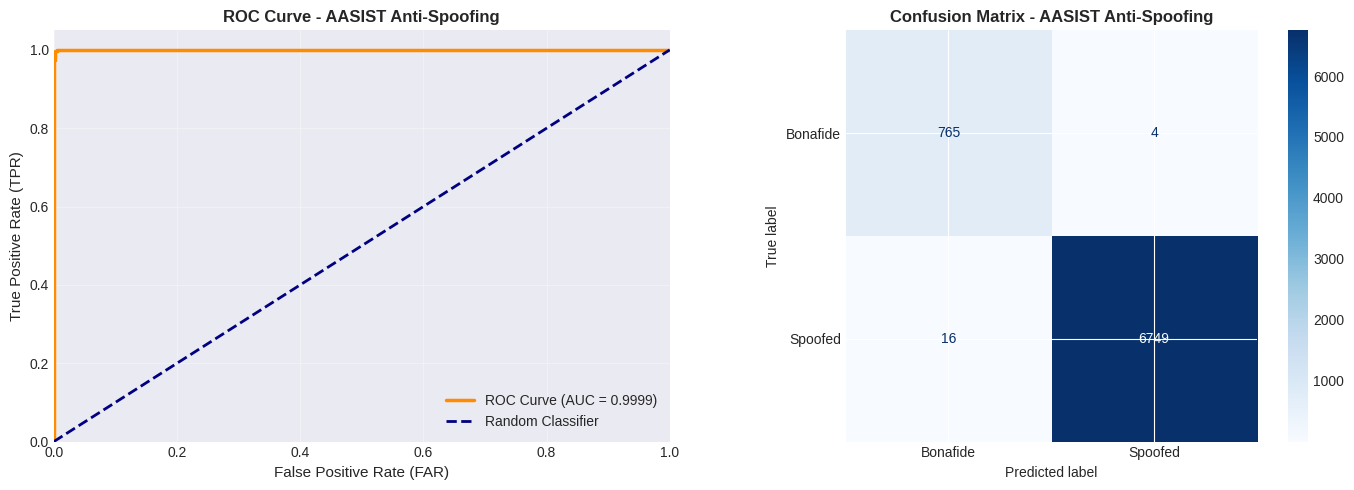

✅ Графики оценки сохранены!


In [19]:
# ============= ЯЧЕЙКА 17: ROC-CURVE И CONFUSION MATRIX (ИСПРАВЛЕННАЯ) =============

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FAR)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[0].set_title('ROC Curve - AASIST Anti-Spoofing', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(True, alpha=0.3)

# Confusion Matrix - ИСПРАВЛЕННАЯ
# КРИТИЧНО: labels=[0, 1] гарантирует размер (2, 2)!
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bonafide', 'Spoofed'])
disp.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Confusion Matrix - AASIST Anti-Spoofing', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plots/module1_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Графики оценки сохранены!")


In [20]:
"""
ИТОГОВЫЙ ОТЧЁТ МОДУЛЯ 1
"""

print("\n" + "="*80)
print("📋 ИТОГОВЫЙ ОТЧЁТ - МОДУЛЬ 1 (AASIST + WavLM)")
print("="*80)

print(f"\n🏗️  АРХИТЕКТУРА МОДЕЛИ:")
print(f"   Feature Extractor: WavLM-large (frozen, 768-dim)")
print(f"   Classifier: AASIST")
print(f"   - Encoder: Linear(768→256) + ReLU + BatchNorm + Dropout")
print(f"   - Attention: MultiheadAttention (8 heads)")
print(f"   - Pooling: Global Average Pooling")
print(f"   - Classifier: Linear(256→128) + Linear(128→2)")

print(f"\n📊 ПАРАМЕТРЫ МОДЕЛИ:")
print(f"   Всего параметров: {total_params:,}")
print(f"   Обучаемых: {trainable_params:,}")
print(f"   WavLM (frozen): {sum(p.numel() for p in wavlm_extractor.parameters()):,}")

print(f"\n📈 ДАННЫЕ ОБУЧЕНИЯ:")
print(f"   Train: {len(train_dataset):5d} файлов")
print(f"   Val:   {len(val_dataset):5d} файлов")
print(f"   Test:  {len(test_dataset):5d} файлов")
print(f"   Batch size: {batch_size}")

print(f"\n🎓 РЕЗУЛЬТАТЫ ОБУЧЕНИЯ:")
print(f"   Epochs completed: {epoch + 1}")
print(f"   Best val loss: {min(history['val_loss']):.4f}")
print(f"   Best val AUC: {max(history['val_auc']):.4f}")
print(f"   Min val EER: {min(history['val_eer']):.4f}")

print(f"\n🎯 ТЕСТОВЫЕ МЕТРИКИ:")
print(f"   Accuracy:  {test_metrics['Accuracy']:.4f}")
print(f"   Precision: {test_metrics['Precision']:.4f}")
print(f"   Recall:    {test_metrics['Recall']:.4f}")
print(f"   F1-score:  {test_metrics['F1']:.4f}")
print(f"   AUC-ROC:   {test_metrics['AUC']:.4f}")
print(f"   EER:       {test_metrics['EER']:.4f}")
print(f"   FAR:       {test_metrics['FAR']:.4f}")
print(f"   FRR:       {test_metrics['FRR']:.4f}")

print(f"\n💾 СОХРАНЁННЫЕ ФАЙЛЫ:")
print(f"   ✅ Модель: {checkpoint_dir}/module1_aasist_best.pth")
print(f"   ✅ История: {RESULTS_DIR}/metrics/training_history.json")
print(f"   ✅ Результаты: {RESULTS_DIR}/metrics/module1_test_results.csv")
print(f"   ✅ Графики: {RESULTS_DIR}/plots/")

print("\n" + "="*80)
print("✅ МОДУЛЬ 1 УСПЕШНО ЗАВЕРШЁН!")
print("="*80)



📋 ИТОГОВЫЙ ОТЧЁТ - МОДУЛЬ 1 (AASIST + WavLM)

🏗️  АРХИТЕКТУРА МОДЕЛИ:
   Feature Extractor: WavLM-large (frozen, 768-dim)
   Classifier: AASIST
   - Encoder: Linear(768→256) + ReLU + BatchNorm + Dropout
   - Attention: MultiheadAttention (8 heads)
   - Pooling: Global Average Pooling
   - Classifier: Linear(256→128) + Linear(128→2)

📊 ПАРАМЕТРЫ МОДЕЛИ:
   Всего параметров: 296,066
   Обучаемых: 296,066
   WavLM (frozen): 315,453,120

📈 ДАННЫЕ ОБУЧЕНИЯ:
   Train: 35156 файлов
   Val:    7534 файлов
   Test:   7534 файлов
   Batch size: 32

🎓 РЕЗУЛЬТАТЫ ОБУЧЕНИЯ:
   Epochs completed: 15
   Best val loss: 0.0046
   Best val AUC: 1.0000
   Min val EER: 0.0000

🎯 ТЕСТОВЫЕ МЕТРИКИ:
   Accuracy:  0.9973
   Precision: 0.9994
   Recall:    0.9976
   F1-score:  0.9985
   AUC-ROC:   0.9999
   EER:       0.0000
   FAR:       0.0052
   FRR:       0.0024

💾 СОХРАНЁННЫЕ ФАЙЛЫ:
   ✅ Модель: /kaggle/working/models/checkpoints/module1_aasist_best.pth
   ✅ История: /kaggle/working/results/metrics/traini

In [1]:
import os

# Проверить наличие файлов
files_to_check = [
    '/kaggle/working/models/checkpoints/module1_aasist_best.pth',
    '/kaggle/working/results/metrics/training_history.json',
    '/kaggle/working/results/metrics/module1_test_results.csv',
    '/kaggle/working/results/plots/training_curves.png',
    '/kaggle/working/results/plots/module1_evaluation.png'
]

print("🔍 ПРОВЕРКА ФАЙЛОВ МОДУЛЯ 1:")
print("="*70)
for file_path in files_to_check:
    exists = os.path.exists(file_path)
    status = "✅ Существует" if exists else "❌ НЕ НАЙДЕН"
    print(f"{status}: {file_path}")


🔍 ПРОВЕРКА ФАЙЛОВ МОДУЛЯ 1:
❌ НЕ НАЙДЕН: /kaggle/working/models/checkpoints/module1_aasist_best.pth
❌ НЕ НАЙДЕН: /kaggle/working/results/metrics/training_history.json
❌ НЕ НАЙДЕН: /kaggle/working/results/metrics/module1_test_results.csv
❌ НЕ НАЙДЕН: /kaggle/working/results/plots/training_curves.png
❌ НЕ НАЙДЕН: /kaggle/working/results/plots/module1_evaluation.png


In [3]:
# В последней ячейке Kaggle notebook
import shutil

# Создать архив
shutil.make_archive('/kaggle/working/module1_results', 'zip', '/kaggle/working/results')
print("✅ Архив создан: /kaggle/working/module1_results.zip")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/results'